# Spectral density as a function of $4t$ for fixed $\mu$ #

## Paper figure

In [36]:
def read_hdf5_file(filename):
    with h5py.File(filename, 'r') as f:
        # Read datasets
        dJUs = f['dJUs'][:]
        en_vector = f['en_vector'][:]
        
        # Initialize matrices
        T11 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T12 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T21 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T22 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T22_F = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        SE_SI = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        
        # Read groups and their datasets
        for i, dJU in enumerate(dJUs):
            group_name = f'dJU_{dJU}'
            group = f[group_name]
            T11[i, :] = group['T11'][:]
            T12[i, :] = group['T12'][:]
            T21[i, :] = group['T21'][:]
            T22[i, :] = group['T22'][:]
            T22_F[i, :] = group['T22_SE'][:]
            SE_SI[i, :] = group['SE_SI'][:]
        
        # Read other datasets
        muU_qcorr = f['muU_qcorr'][:]
        omega0s = f['omega0s'][:]
        omega1s = f['omega1s'][:]
        omega2s = f['omega2s'][:]
        
        # Read attributes
        UIB = f.attrs['UIB']
        Lx = f.attrs['Lx']
        Ly = f.attrs['Ly']
        N = f.attrs['N']
        dOmega = en_vector[1] - en_vector[0]
        eta = 0.01  #0.01# 
        SpectralFuncs = np.zeros((len(dJUs), len(en_vector)), dtype = float)
        for count in range(0, len(dJUs)):
            SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
    
    return {
        'dJUs': dJUs,
        'muU_qcorr': muU_qcorr,
        'en_vector': en_vector,
        'omega0s': omega0s,
        'omega1s': omega1s,
        'omega2s': omega2s,
        'T11': T11,
        'T12': T12,
        'T21': T21,
        'T22': T22,
        'T22_F': T22_F,
        'SE_SI': SE_SI,
        'UIB': UIB,
        'Lx': Lx,
        'Ly': Ly,
        'N': N,
        'SpectralFuncs': SpectralFuncs
    }
# # construct the spectral function and T-matrices 
# SpectralFuncs = np.zeros((len(dJUs), len(en_vector)), dtype = float)
# Sigma = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
# Sigma00 = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
# dOmega = en_vector[1] - en_vector[0]
# eta = 0.01  #0.01# 

# #
# for count in range(0, len(dJUs)):
#     SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
#     Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
#     Sigma00[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count])


### UIB > 0 plot

In [37]:
# QMC data from Matija
import numpy as np
# conversion between MC and QGW 
# MC data in MI at UIB = 1.5 U
# 0.75 value is interpolate for UIB 1p5
# all values are interpolated for UIB -1p5
MC_to_QGW = 0.1292 / ( 4 * 0.045) # qgw / MC
#hopping
t_Matija_MC= np.array([0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05,0.055,0.06,0.065,0.07,0.075])

#energies
Ep_Matija_UIB_1p5 = np.array([0.9567070954561756, 0.9340805627948908, 0.9107186916248076, 0.8861927409299135, 0.8604789058505025, 0.8327420217817956, 0.8017973574594149, 0.7662565000726773, 0.7228130739116233, 0.6701046185604801, 0.6243495894387097, 0.6192476250462631, 0.6437855177669339, 0.669550671966299])
Ep_Matija_UIB_1p0 = np.array([0.958692485930198, 0.9363945038702304, 0.913280044762147, 0.8886879359927147, 0.8625134012004564, 0.8340913634829621, 0.8022988912921551, 0.7645791829785881, 0.7188149232019857, 0.6610843959109023, 0.6063995355883616, 0.5876536767087501, 0.5972355465556634, 0.6108417696325573])
Ep_Matija_UIB_0p5 = np.array([0.4994997846414343, 0.4988756137396564, 0.4980325558426537, 0.4970178720385532, 0.4957061390719834, 0.4942184387394613, 0.4927352169288472, 0.4911583357726482, 0.4891478318235325, 0.4814663355157805, 0.4595165347460798, 0.4351646539805932, 0.4255063722945399, 0.4217218260375296])

Ep_Error_UIB_0p5 = np.array([7.484417168291046e-06, 2.6168948745684585e-05, 5.662857848701037e-06, 6.0222567221871984e-05, 6.279123347181529e-05, 0.000128267952606, 0.0003275742644659, 0.000526545483409, 0.0004883388647774, 0.0004751141548741, 0.0001168969824305, 0.0001861537940815, 0.0005765257634276, 0.0004905091507313])
Ep_Error_UIB_1p0 = np.array([0.0001113761574579, 4.4022300085800494e-05, 5.555242071658097e-05, 6.79996310897755e-05, 0.0001535804369059, 0.0002365592367596, 0.0007221437432685, 0.0016082348299508, 0.002433486829359, 0.0024665002110615, 7.058939822761214e-05, 0.0014817635112459, 0.0034848008962914, 0.003122693204063])
Ep_Error_UIB_1p5 = np.array([0.0003826687656929, 0.0005513163176704, 0.0007002244525732, 0.0009519925157594, 0.0011382811840876, 0.0015123043108077, 0.0021297797352106, 0.0029699228805084, 0.004072089637243, 0.0039545977913403, 0.0010335096971897, 0.0030192153066925, 0.0052703840298407, 0.0047269712553137])
#conversion
t_Matija_QGW = MC_to_QGW * t_Matija_MC   
dJUs_Matija_QGW = 4 * t_Matija_QGW

In [38]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

import h5py
import numpy as np
eta = 0.01
desired_n0 = 1.01 # desired density line
M = 100
cutoff = 3

UIB = 0.5
filename05 = f'../data/non_integer_filling/UIB_{UIB}_Mu_M_{M}_nqcorr_{desired_n0}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.hdf5'
print(filename05)
data05 = read_hdf5_file(filename05)
omega0s = data05['omega0s']
omega1s = data05['omega1s']
omega2s = data05['omega2s']
SpectralFuncs05 = data05['SpectralFuncs']
pert05 = omega0s + omega1s + omega2s

UIB = 1.0
filename10 = f'../data/non_integer_filling/UIB_{UIB}_Mu_M_{M}_nqcorr_{desired_n0}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.hdf5'
print(filename10)
data10 = read_hdf5_file(filename10)
omega0s = data10['omega0s']
omega1s = data10['omega1s']
omega2s = data10['omega2s']
SpectralFuncs10 = data10['SpectralFuncs']
pert10 = omega0s + omega1s + omega2s

UIB = 1.5
filename15 = f'../data/non_integer_filling/UIB_{UIB}_Mu_M_{M}_nqcorr_{desired_n0}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.hdf5'
print(filename15)
data15 = read_hdf5_file(filename15)
omega0s = data15['omega0s']
omega1s = data15['omega1s']
omega2s = data15['omega2s']
SpectralFuncs15 = data15['SpectralFuncs']
pert15 = omega0s + omega1s + omega2s


dJUs = data15['dJUs']
en_vector = data15['en_vector']
muUs = data15['muU_qcorr']
# First row of SpectralFuncs05 should be equal to second

SpectralFuncs05[0, :] = SpectralFuncs05[1, :]

../data/non_integer_filling/UIB_0.5_Mu_M_100_nqcorr_1.01_eta_0.01_cutoff_3_full_crossover_slim.hdf5
../data/non_integer_filling/UIB_1.0_Mu_M_100_nqcorr_1.01_eta_0.01_cutoff_3_full_crossover_slim.hdf5
../data/non_integer_filling/UIB_1.5_Mu_M_100_nqcorr_1.01_eta_0.01_cutoff_3_full_crossover_slim.hdf5


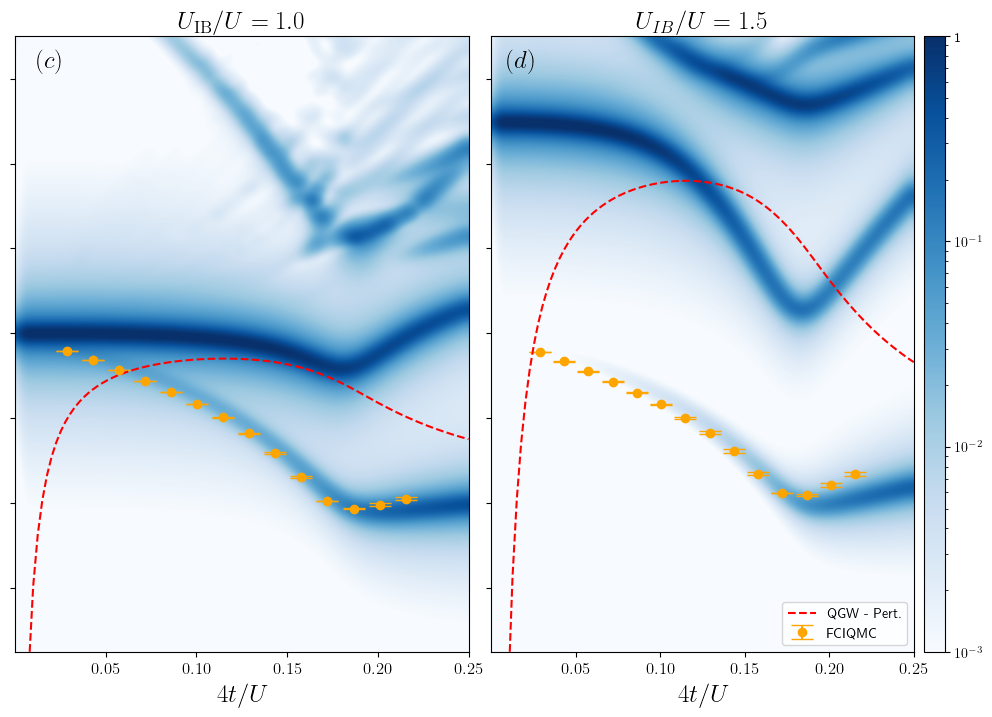

In [ ]:
def custom_formatter(x, pos):
    if x == 1:
        return '1'
    else:
        return f'$10^{{{int(np.log10(x))}}}$'



import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['text.usetex'] = True
colorqmc = 'orange'
markerqmc = '.'

# Rotate the image by -90 degrees
SpectralFuncs_rot05 = np.abs(np.rot90(SpectralFuncs05, 1))
SpectralFuncs_rot10 = np.abs(np.rot90(SpectralFuncs10, 1))
SpectralFuncs_rot15 = np.abs(np.rot90(SpectralFuncs15, 1))


# Apply Gaussian filter to smooth the data
sigma =1  # Adjust sigma to control the amount of smoothing
SpectralFuncs_rot05 = gaussian_filter(SpectralFuncs_rot05, sigma=sigma)
SpectralFuncs_rot10 = gaussian_filter(SpectralFuncs_rot10, sigma=sigma)
SpectralFuncs_rot15 = gaussian_filter(SpectralFuncs_rot15, sigma=sigma)

fig, (ax2, ax3) = plt.subplots(ncols = 2, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 'auto'
interp = 'bicubic'
color_map = 'Blues'
extent = [min(dJUs), max(dJUs),min(en_vector), max(en_vector) ]

# im1 = ax1.imshow( np.abs(SpectralFuncs_rot05), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())

im2 = ax2.imshow(np.abs(SpectralFuncs_rot10), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())

im3 = ax3.imshow(np.abs(SpectralFuncs_rot15), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())


# ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax2.set_xlabel(r'$4t/U$', fontsize=14)
ax3.set_xlabel(r'$4t/U$', fontsize=14)
# ax1.set_ylabel(r'$\omega/U$', fontsize=14)
# ax1.set_ylim(en_vector[0], en_vector[-1])
# ax1.set_xlabel(r'$4t/U$', fontsize=14)
# ax1.set_ylabel(r'$\omega/U$', fontsize=14)
ax2.set_ylim(en_vector[0], en_vector[-1])
ax2.set_xlabel(r'$4t/U$', fontsize=18)
# ax2.set_ylabel(r'$\omega/U$', fontsize=14)
ax3.set_ylim(en_vector[0], en_vector[-1])
ax3.set_xlabel(r'$4t/U$', fontsize=18)
# ax3.set_ylabel(r'$\omega/U$', fontsize=14)

# ax1.set_title(r'$U_{\mathrm{IB}}/U = 0.5$', fontsize=14)
ax2.set_title(r'$U_{\mathrm{IB}}/U = 1.0$', fontsize=18)
ax3.set_title(r'$U_{\mathrm{IB}}/U = 1.5$', fontsize=18)

# im1.set_clim(1e-3, 1e0)
im2.set_clim(1e-3, 1e0)
im3.set_clim(1e-3, 1e0)

# Create a divider for ax3 to place the colorbar
divider3 = make_axes_locatable(ax3)

# Append an axis for the colorbar to the right of ax3
cax3 = divider3.append_axes("right", size="5%", pad=0.1)

# Create the colorbar
cb3 = plt.colorbar(im3, cax=cax3, orientation="vertical")


# Apply the custom formatter to the colorbar
cb3.ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
# cb3.set_label(label = "-2$\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')


# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_0p5
plot_y_errors = Ep_Error_UIB_0p5
#ax1.scatter(plot_x,plot_y)
# ax1.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert05
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
# ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)

# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_1p0
plot_y_errors = Ep_Error_UIB_1p0
#ax1.scatter(plot_x,plot_y)
ax2.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert10
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax2.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)


# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_1p5
plot_y_errors = Ep_Error_UIB_1p5
#ax1.scatter(plot_x,plot_y)
ax3.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert15
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax3.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)
# ax1.legend(loc='upper right')

# Set y-axis limits for all three plots
ylim_lower = 0.25
ylim_upper = 1.7
# ax1.set_ylim(ylim_lower, ylim_upper)
# ax1.tick_params(axis='x', which='major', labelsize=12) 
# ax1.tick_params(axis='y', which='major', labelsize=12) 

ax2.set_ylim(ylim_lower, ylim_upper)
ax3.set_ylim(ylim_lower, ylim_upper)
ax2.set_yticklabels([])
ax3.set_yticklabels([])
plt.subplots_adjust(wspace=0.05)

xticks = ax2.get_xticks()
xticklabels = ax2.get_xticklabels()
# increase tick marler size
ax2.tick_params(axis='x', which='major', labelsize=12) 

ax2.set_xticks(xticks[1:])
ax2.set_xticklabels(xticklabels[1:])

xticks = ax3.get_xticks()
xticklabels = ax3.get_xticklabels()
ax3.tick_params(axis='x', which='major', labelsize=12) 
ax3.set_xticks(xticks[1:])
ax3.set_xticklabels(xticklabels[1:])

# Add labels (a), (b), and (c) to the panels
# ax1.text(0.13, 0.98, r'$(a)$', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
ax2.text(0.11, 0.98, r'$(c)$', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
ax3.text(0.11, 0.98, r'$(d)$', transform=ax3.transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
ax3.legend(loc='lower right')
plt.show()


In [40]:
# QMC data from Matija
import numpy as np

# conversion between MC and QGW 
# MC data in MI at UIB = 1.5 U
# 0.75 value is interpolate for UIB 1p5
# all values are interpolated for UIB -1p5
MC_to_QGW = 0.1292 / ( 4 * 0.045) # qgw / MC


#hopping
t_Matija_MC= np.array([0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05,0.055,0.06,0.065,0.07,0.075])
#energies
Ep_Matija_UIB_1p5 = np.array([0.9564626057,0.9336809943,0.9100511069,0.8853755808,0.8590815707,0.8309053212,0.7991644585,0.762848257,0.7190450017,0.6667375136,0.6221272652,0.6166042472,0.6400243702,0.6655410675])
Ep_Matija_UIB_1p0 = np.array([0.9587093145,0.9364059961,0.913219459,0.8885494595,0.8621197323,0.8333712351,0.8009601262,0.7626794911,0.7159211234,0.659379226,0.6060795453,0.5873374183,0.5949207444,0.6090832515])
Ep_Matija_UIB_0p5 = np.array([0.4994887388,0.4988958469,0.498083353,0.4970997236,0.4959171713,0.4946263455,0.4931991863,0.491692903,0.4888610017,0.480440858,0.4587387917,0.4353459947,0.4251578658,0.4210527202])
Ep_Matija_UIB_m0p5 = np.array([-0.5005101622,-0.5011031536,-0.5019059981,-0.5028779997,-0.5040446895,-0.5053021229,-0.5067590036,-0.5083781865,-0.5104402917,-0.5164005131,-0.5317570535,-0.5511854567,-0.562564214,-0.5680343593])
Ep_Matija_UIB_m1p0 = np.array([-1.017345291,-1.026549991,-1.035636545,-1.046563127,-1.058126019,-1.072136958,-1.090599545,-1.1170411,-1.157332996,-1.217675254,-1.286872403,-1.329275248,-1.342824562,-1.346340987])
Ep_Matija_UIB_m1p5 = np.array([-2.005046061,-2.010877559,-2.0188552,-2.029554248,-2.04333265,-2.060918635,-2.084478325,-2.116223715,-2.163363013,-2.233592827,-2.315400502,-2.363951663,-2.378549341,-2.378937433])
#error bars
Ep_Error_UIB_m1p5 = np.array([0.0002538392296,0.0003353137729,0.000288825283,0.0002573811918,0.0005067805106,0.0007948796509,0.001792606071,0.004244092211,0.007089050072,0.007603642652,0.002495617669,0.002660506845,0.006036178469,0.008733482878])
Ep_Error_UIB_m1p0 = np.array([0.0006097454727,0.001070603418,0.001755243756,0.001818520564,0.002319438696,0.001956422859,0.0004183186896,0.002343735575,0.005684065265,0.005855149478,0.000393835455,0.0001088368206,0.003753130631,0.005289380022])
Ep_Error_UIB_m0p5 = np.array([5.26E-06,4.17E-05,8.45E-05,0.0001569480054,0.0003008712359,0.0005406478398,0.0008602355436,0.001189879433,0.0007998321263,0.0004891497351,0.0009730377156,0.0002539785821,0.0006714935397,0.00131688987])
Ep_Error_UIB_0p5 = np.array([3.85E-06,3.88E-05,9.67E-05,0.0001777824868,0.0003803892146,0.0006995051929,0.001048335879,0.001264652607,0.0004758088953,0.001589771265,0.001180884721,0.0003777081827,0.001060725446,0.001648476215])
Ep_Error_UIB_1p0 = np.array([0.0001171796678,2.96E-05,0.0001341764073,0.0002091340446,0.0006056439733,0.001286065702,0.002518851405,0.004483749766,0.007391572799,0.005535996016,0.0006795253077,0.003090237587,0.00719487393,0.007826187606])
Ep_Error_UIB_1p5 = np.array([0.0008020356698,0.001168604462,0.001729680543,0.00226964684,0.003108692815,0.004321065192,0.005975374025,0.008212387916,0.009965181068,0.008530746948,0.00401867947,0.006316677637,0.01054419804,0.01093456396])
#conversion
t_Matija_QGW = MC_to_QGW * t_Matija_MC   
dJUs_Matija_QGW = 4 * t_Matija_QGW

In [41]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import h5py
import numpy as np
import class_utils as class_utils
import matplotlib
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from scipy import interpolate

In [42]:
config_path = "config.yml" 

output_dir = class_utils.create_output_dir()
config = class_utils.read_config(config_path)

# # load fixed density data 
# dJUs_grid = np.loadtxt('./ragheed_data/dJU_values_nqcorr_1.csv',delimiter=',',skiprows=1).transpose()
# muUs_grid = np.loadtxt('./ragheed_data/muU_values_nqcorr_1.csv',delimiter=',',skiprows=1)

# # create interpolating function
# f = interpolate.interp1d(dJUs_grid, muUs_grid)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
UIB = config["physics"]["UIB"]
M = Lx * Ly

grid = Grid(Lx, Ly)

UIB = 1.0

num_en = 200 # 100 gets pretty good resolution.  takes at least an hour then.
num_dJU = 200 # 100
dJU_max = 0.2154#0.2154
dJU_min = 0.02871#0.1292
en_vector = np.linspace(0, 2, num_en)#0.001,0.5,num_en) #0.001, 0.5,num_en)
dJUs = np.linspace(dJU_min, dJU_max, num_dJU)
# muUs = f(dJUs)

In [43]:
# We calculate fixed density lines for a range of dJU values

import numpy as np
import class_utils as utils
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_plotting import plot2D, plot_cns, plot_omega0
from matplotlib import pyplot as plt
from class_io import IO

config_path = "config.yml" 

output_dir = utils.create_output_dir()

config = utils.read_config(config_path)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]

N = config["physics"]["N"]
dJUs = np.linspace(**config["lists"]["dJUs"])
dJU = dJUs[0]
muU = eval(config["physics"]["muU"])
UIB = config["physics"]["UIB"]
cutoff = config["physics"]["cutoff"]

grid = Grid(Lx, Ly)
params = Params(N, dJU, muU, UIB, cutoff)
io = IO()

desired_n0 = 1.01 # desired density line
muU_qcorr = np.zeros(len(dJUs))
dJUmax = (np.sqrt(desired_n0 + 1) - np.sqrt(desired_n0))**2

def n0_corr(muU, dJU, UIB, cutoff, desired_n0):
    params = Params(N, dJU, muU, UIB, cutoff)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    pert = perturbative(grid, params, verts, omegaklambda)
    eq = pert.sigma0(n0) / UIB
    return eq - desired_n0

def findroot(mu_start, mu_step, dJU, UIB, cutoff, desired_n0):
    n_1 = n0_corr(mu_start, dJU, UIB, cutoff, desired_n0)
    n_2 = n0_corr(mu_start + mu_step, dJU, UIB, cutoff, desired_n0)
    
    # print(mu_start, n_1 , n_2)
    if(n_1 * n_2 > 0):
        return findroot(mu_start + mu_step, mu_step, dJU, UIB, cutoff, desired_n0)
    else:
        n_mid = n0_corr(mu_start + mu_step / 2, dJU, UIB, cutoff, desired_n0)
        if(np.abs(n_mid) < 1e-6):
            return mu_start + mu_step / 2
        elif(n_mid * n_1 < 0):
            return findroot(mu_start, mu_step / 2, dJU, UIB, cutoff, desired_n0)
        else:
            return findroot(mu_start + mu_step / 2, mu_step / 2, dJU, UIB, cutoff, desired_n0)

initial_guess = 1

muU_qcorr[0] = 1
# start with large values of dJU and decrease it 
for count in range(1, len(dJUs)):
    dJU = dJUs[count]
    found = False
    mu_start = muU_qcorr[count - 1] - 0.15
    mu_step = 0.05
    muU_qcorr[count] = findroot(mu_start, mu_step, dJU, UIB, cutoff, desired_n0)
    print("dJU = ", dJU, "muU = ", muU_qcorr[count])
    initial_guess = muU_qcorr[count]
    
muUs = muU_qcorr
# io.save_to_hdf5_fixed_density_qcorr(grid, params, desired_n0, dJUs, muU_qcorr)

KeyboardInterrupt: 

In [ ]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

import h5py
import numpy as np

def read_hdf5_file(filename):
    with h5py.File(filename, 'r') as f:
        # Read datasets
        dJUs = f['dJUs'][:]
        en_vector = f['en_vector'][:]
        
        # Initialize matrices
        T11 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T12 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T21 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T22 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T22_F = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        SE_SI = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        
        # Read groups and their datasets
        for i, dJU in enumerate(dJUs):
            group_name = f'dJU_{dJU}'
            group = f[group_name]
            T11[i, :] = group['T11'][:]
            T12[i, :] = group['T12'][:]
            T21[i, :] = group['T21'][:]
            T22[i, :] = group['T22'][:]
            T22_F[i, :] = group['T22_SE'][:]
            SE_SI[i, :] = group['SE_SI'][:]
        
        # Read other datasets
        muU_qcorr = f['muU_qcorr'][:]
        omega0s = f['omega0s'][:]
        omega1s = f['omega1s'][:]
        omega2s = f['omega2s'][:]
        
        # Read attributes
        UIB = f.attrs['UIB']
        Lx = f.attrs['Lx']
        Ly = f.attrs['Ly']
        N = f.attrs['N']
    
    return {
        'dJUs': dJUs,
        'muU_qcorr': muU_qcorr,
        'en_vector': en_vector,
        'omega0s': omega0s,
        'omega1s': omega1s,
        'omega2s': omega2s,
        'T11': T11,
        'T12': T12,
        'T21': T21,
        'T22': T22,
        'T22_F': T22_F,
        'SE_SI': SE_SI,
        'UIB': UIB,
        'Lx': Lx,
        'Ly': Ly,
        'N': N
    }

eta = 0.01
desired_n0 = 0.99 # desired density line
UIB = -1.0
M = 100
cutoff = 3
filename = f'../data/non_integer_filling/UIB_{UIB}_Mu_M_{M}_nqcorr_{desired_n0}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.hdf5'
data = read_hdf5_file(filename)

# Access the data
dJUs = data['dJUs']
T11 = data['T11']
T12 = data['T12']
T21 = data['T21']
T22 = data['T22']
T22_F = data['T22_F']
SE_SI = data['SE_SI']

omega0s = data['omega0s']
omega1s = data['omega1s']
omega2s = data['omega2s']

muUs = data['muU_qcorr']
en_vector = data['en_vector']

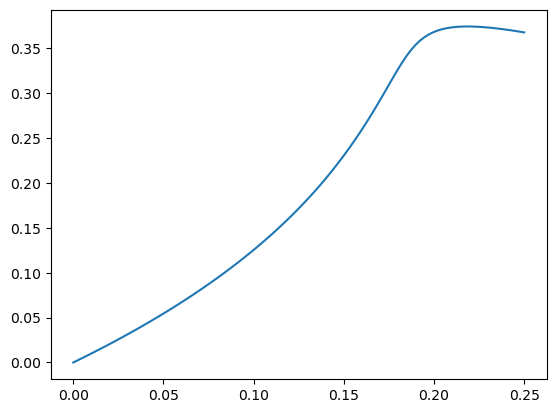

In [ ]:
# import matplotlib.pyplot as plt

plt.plot(dJUs, muUs)
plt.show()

In [ ]:
# run this block if you are making the data for the first time

# input("confirm that you would like to make the data for the first time")
en_vector = np.linspace(0.25, 2, 200)

omega0s = np.zeros(len(dJUs))
omega1s = np.zeros(len(dJUs))
omega2s = np.zeros(len(dJUs))

SE = np.zeros((7, len(en_vector)), dtype=np.complex128)  #7 rows for each contribution, num_en columns ##V: why 7?
UIB = 1.5

#V:  Add poles to this plot!!!
T11 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T12 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T21 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T22 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
T22_F = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
SE_SI = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)

for count, dJU in enumerate(dJUs):
    muU = muUs[count]
    print(count,dJU,muU)
    params = Params(N, dJU, muU, UIB, cutoff)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    omega0s[count] = Pert_Energy[0]
    omega1s[count] = Pert_Energy[1]
    omega2s[count] = Pert_Energy[2]
    print(n0, pert.sigma0(n0) / UIB)

    for epol_ind in range(len(en_vector)):
        # # Non-self consistent
        # Epol_NSC = en_vector[epol_ind] - UIB
        # self_energy = Self_Energy(Epol_NSC, grid, params, verts, omegaklambda)
        # output_NSC = self_energy.calculate_self_energy()
        # # Self consistent
        Epol_SC = en_vector[epol_ind] - pert.sigma0(n0) #output_NSC[6]
        self_energy = Self_Energy(Epol_SC, grid, params, verts, omegaklambda)
        output_SC = self_energy.calculate_self_energy()
        SE[:, epol_ind] = output_SC
    #The zeroth element is the full self energy minus w, used for finding the zero crossings.
    T11[count, :] = SE[1, :]
    T12[count, :] = SE[2, :]
    T21[count, :] = SE[3, :]
    T22[count, :] = SE[4, :]
    T22_F[count, :] = SE[5, :]
    SE_SI[count, :] = SE[6, :]

0 0.0 0.0


NameError: name 'N' is not defined

In [ ]:
# construct the spectral function and T-matrices 
SpectralFuncs = np.zeros((len(dJUs), len(en_vector)), dtype = float)
Sigma = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
Sigma00 = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
dOmega = en_vector[1] - en_vector[0]
eta = 0.01  #0.01# 

#
for count in range(0, len(dJUs)):
    SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
    Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
    Sigma00[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count])

<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
/var/folders/g4/_3tbwn011fj7jk_lzv3jctnh0000gn/T/ipykernel_44455/3686458436.py:54: SyntaxWarning: invalid escape sequence '\o'
  cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
/var/folders/g4/_3tbwn011fj7jk_lzv3jctnh0000gn/T/ipykernel_44455/3686458436.py:56: SyntaxWarning: invalid escape sequence '\m'
  cb2.set_label(label = "-2$\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
/var/folders/g4/_3tbwn011fj7jk_lzv3jctnh0000gn/T/ipykernel_44455/3686458436.py:58: SyntaxWarning: invalid escape sequence '\m'
  cb3.set_label(label = "-2$\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')


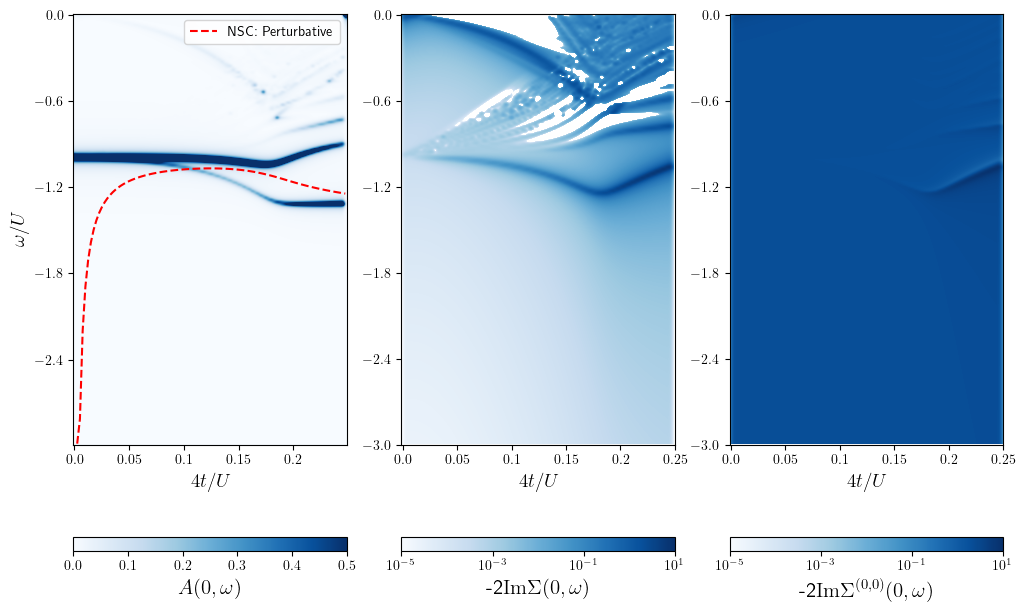

In [ ]:
plt.rcParams['text.usetex'] = True


# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 'auto'
interp = 'Bicubic'
color_map = 'Blues'
im1 = ax1.imshow( np.abs(SpectralFuncs_rot), interpolation = interp, cmap = color_map, aspect = aspect_ratio)#, norm=matplotlib.colors.LogNorm())
im2 = ax2.imshow(-2 * np.imag(Sigma_rot), interpolation = interp,cmap = color_map, aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im3 = ax3.imshow(2 * np.abs(Sigma00_rot), interpolation = interp,cmap = color_map, aspect = aspect_ratio,norm=matplotlib.colors.LogNorm())


# Select a subset of dJUs and en_vector for the ticks
num_xticks = 6
num_yticks = 6

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(dJUs), max(dJUs), num_xticks), 2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)
ax2.set_xticks(xticks)
ax2.set_yticks(yticks)
ax3.set_xticks(xticks)
ax3.set_yticks(yticks)
ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)
ax2.set_xticklabels(xticklabels)
ax2.set_yticklabels(yticklabels)
ax3.set_xticklabels(xticklabels)
ax3.set_yticklabels(yticklabels)
ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax2.set_xlabel(r'$4t/U$', fontsize=14)
ax3.set_xlabel(r'$4t/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
cb2 = plt.colorbar(im2,orientation="horizontal")
cb2.set_label(label = "-2$\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
cb3 = plt.colorbar(im3,orientation="horizontal")
cb3.set_label(label = "-2$\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')
im1.set_clim(0, 0.5)
im2.set_clim(1e-5, 1e1)
im3.set_clim(1e-5, 1e1)



X, Y = np.meshgrid(dJUs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(dJUs, (dJUs.min(), dJUs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
#plot_y_pole = SpectralFuncs_rot.shape[0] - 1 - np.interp(pol_w, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))


# Overlay the plot on top of the imshow figure
ax1.plot(plot_x, plot_y, linestyle='--', label='NSC:  Perturbative', color='red', linewidth=1.5)
#ax1.plot(plot_x[20:-1], plot_y_pole[20:-1], linestyle = ':', label='Lowest Pole T-matrix', color='green', linewidth=2)
#ax2.plot(plot_x[20:-1], plot_y_pole[20:-1], linestyle = ':', label='Lowest Pole T-matrix', color='green', linewidth=2)
ax1.legend()
#ax2.legend()
# ax1.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = '.',markersize = 4,linestyle = 'none',capsize = 3, label='FCI-QMC', color='lime')
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
/var/folders/g4/_3tbwn011fj7jk_lzv3jctnh0000gn/T/ipykernel_44455/2068922548.py:21: SyntaxWarning: invalid escape sequence '\o'
  cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
/var/folders/g4/_3tbwn011fj7jk_lzv3jctnh0000gn/T/ipykernel_44455/2068922548.py:21: SyntaxWarning: invalid escape sequence '\o'
  cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')


NameError: name 'Lx' is not defined

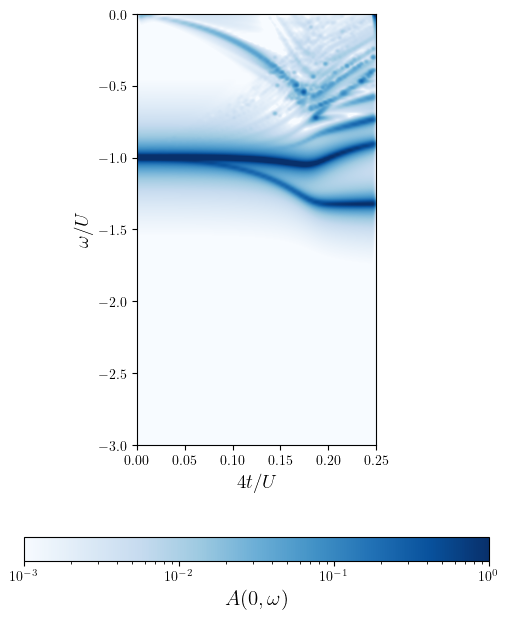

In [ ]:

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)


fig, ax1 = plt.subplots(ncols = 1, figsize = (6,8)) # (6,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 0.15#0.1#'auto' # 0.15 for UIB >0, 0.1 for UIB < 0
color_map = 'Blues'
interp = 'bicubic'
extent = [min(dJUs), max(dJUs),min(en_vector), max(en_vector) ]
im1 = ax1.imshow(np.abs(SpectralFuncs_rot), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=matplotlib.colors.LogNorm())
ax1.set_ylim(en_vector[0], en_vector[-1])
ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
im1.set_clim(1e-3,1e0)


idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0


M = Lx * Ly
# # # plot the extrapolated MC data.
Ep_M = Ep_Matija_UIB_1p0
Errors_M = Ep_Error_UIB_1p0
dJUs_M = dJUs_Matija_QGW
plot_x = dJUs_M
plot_y = Ep_M
plot_y_errors = Errors_M
#ax1.scatter(plot_x,plot_y)
ax1.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = '.',markersize = 4,linestyle = 'none',capsize = 3, label='FCI-QMC', color='lime')

#plot perturbative result
plot_x = dJUs
plot_y = omega0s + omega1s + omega2s
fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)


ax1.legend()

plt.show()

In [ ]:
## Save the figure 
filename = f'../figs/self_consistent_t/non_integer_filling/UIB_{UIB}_Mu_M_{grid.M}_nqcorr_{desired_n0}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')

In [ ]:
# Save the data

# Code to save results for different UIBs
filename = f'../data/non_integer_filling/UIB_{UIB}_Mu_M_{grid.M}_nqcorr_{desired_n0}_eta_{eta}_cutoff_{cutoff}_full_crossover_slim.hdf5'

with h5py.File(filename, 'w') as f:
    f.create_dataset('dJUs', data=dJUs)
    f.create_dataset('muU_qcorr', data=muU_qcorr)
    f.create_dataset('en_vector', data=en_vector)
    f.create_dataset('omega0s', data=omega0s)
    f.create_dataset('omega1s', data=omega1s)
    f.create_dataset('omega2s', data=omega2s)

    for i, dJU in enumerate(dJUs):
    # Create a group for this dJU value
        # print(i, dJU)
        group = f.create_group(f'dJU_{dJU}')
        # store one value of muU_qcorr for each dJU
        group.attrs['muU'] = muU_qcorr[i]
        # Store the arrays in this group
        group.create_dataset('T11', data=T11[i,:])
        group.create_dataset('T12', data=T12[i,:])
        group.create_dataset('T21', data=T21[i,:])
        group.create_dataset('T22', data=T22[i,:])
        group.create_dataset('T22_SE', data=T22_F[i,:])
        group.create_dataset('SE_SI', data=SE_SI[i,:])
    

    # Create attributes for your parameters
    f.attrs['UIB'] = UIB
    
    f.attrs['Lx'] = grid.Lx
    f.attrs['Ly'] = grid.Ly
    f.attrs['N'] = N
    
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]


## Paper figure

In [80]:
def read_hdf5_file(filename):
    with h5py.File(filename, 'r') as f:
        # Read datasets
        dJUs = np.linspace(0.02871,0.2154,200)
        en_vector = f['en_vector'][:]
        
        # Initialize matrices
        T11 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T12 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T21 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T22 = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        T22_F = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        SE_SI = np.zeros((len(dJUs), len(en_vector)), dtype=np.complex128)
        
        # Read groups and their datasets
        for i, dJU in enumerate(dJUs):
            group_name = f'dJU_{dJU}'
            group = f[group_name]
            T11[i, :] = group['T11'][:]
            T12[i, :] = group['T12'][:]
            T21[i, :] = group['T21'][:]
            T22[i, :] = group['T22'][:]
            T22_F[i, :] = group['T22_SE'][:]
            SE_SI[i, :] = group['SE_SI'][:]
        
        # Read other datasets
        omega0s = f['omega0s'][:]
        omega1s = f['omega1s'][:]
        omega2s = f['omega2s'][:]
        
        # Read attributes
        UIB = f.attrs['UIB']
        Lx = f.attrs['Lx']
        Ly = f.attrs['Ly']
        N = f.attrs['N']
        dOmega = en_vector[1] - en_vector[0]
        eta = 0.01  #0.01# 
        SpectralFuncs = np.zeros((len(dJUs), len(en_vector)), dtype = float)
        for count in range(0, len(dJUs)):
            SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
    
    return {
        'dJUs': dJUs,
        'en_vector': en_vector,
        'omega0s': omega0s,
        'omega1s': omega1s,
        'omega2s': omega2s,
        'T11': T11,
        'T12': T12,
        'T21': T21,
        'T22': T22,
        'T22_F': T22_F,
        'SE_SI': SE_SI,
        'UIB': UIB,
        'Lx': Lx,
        'Ly': Ly,
        'N': N,
        'SpectralFuncs': SpectralFuncs
    }
# # construct the spectral function and T-matrices 
# SpectralFuncs = np.zeros((len(dJUs), len(en_vector)), dtype = float)
# Sigma = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
# Sigma00 = np.zeros((len(dJUs), len(en_vector)),dtype=np.complex128)
# dOmega = en_vector[1] - en_vector[0]
# eta = 0.01  #0.01# 

# #
# for count in range(0, len(dJUs)):
#     SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
#     Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
#     Sigma00[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count])


### UIB > 0 plot

In [81]:
# QMC data from Matija
import numpy as np
# conversion between MC and QGW 
# MC data in MI at UIB = 1.5 U
# 0.75 value is interpolate for UIB 1p5
# all values are interpolated for UIB -1p5
MC_to_QGW = 0.1292 / ( 4 * 0.045) # qgw / MC
#hopping
t_Matija_MC= np.array([0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05,0.055,0.06,0.065,0.07,0.075])

#energies
Ep_Matija_UIB_1p5 = np.array([0.9567070954561756, 0.9340805627948908, 0.9107186916248076, 0.8861927409299135, 0.8604789058505025, 0.8327420217817956, 0.8017973574594149, 0.7662565000726773, 0.7228130739116233, 0.6701046185604801, 0.6243495894387097, 0.6192476250462631, 0.6437855177669339, 0.669550671966299])
Ep_Matija_UIB_1p0 = np.array([0.958692485930198, 0.9363945038702304, 0.913280044762147, 0.8886879359927147, 0.8625134012004564, 0.8340913634829621, 0.8022988912921551, 0.7645791829785881, 0.7188149232019857, 0.6610843959109023, 0.6063995355883616, 0.5876536767087501, 0.5972355465556634, 0.6108417696325573])
Ep_Matija_UIB_0p5 = np.array([0.4994997846414343, 0.4988756137396564, 0.4980325558426537, 0.4970178720385532, 0.4957061390719834, 0.4942184387394613, 0.4927352169288472, 0.4911583357726482, 0.4891478318235325, 0.4814663355157805, 0.4595165347460798, 0.4351646539805932, 0.4255063722945399, 0.4217218260375296])

Ep_Error_UIB_0p5 = np.array([7.484417168291046e-06, 2.6168948745684585e-05, 5.662857848701037e-06, 6.0222567221871984e-05, 6.279123347181529e-05, 0.000128267952606, 0.0003275742644659, 0.000526545483409, 0.0004883388647774, 0.0004751141548741, 0.0001168969824305, 0.0001861537940815, 0.0005765257634276, 0.0004905091507313])
Ep_Error_UIB_1p0 = np.array([0.0001113761574579, 4.4022300085800494e-05, 5.555242071658097e-05, 6.79996310897755e-05, 0.0001535804369059, 0.0002365592367596, 0.0007221437432685, 0.0016082348299508, 0.002433486829359, 0.0024665002110615, 7.058939822761214e-05, 0.0014817635112459, 0.0034848008962914, 0.003122693204063])
Ep_Error_UIB_1p5 = np.array([0.0003826687656929, 0.0005513163176704, 0.0007002244525732, 0.0009519925157594, 0.0011382811840876, 0.0015123043108077, 0.0021297797352106, 0.0029699228805084, 0.004072089637243, 0.0039545977913403, 0.0010335096971897, 0.0030192153066925, 0.0052703840298407, 0.0047269712553137])
#conversion
t_Matija_QGW = MC_to_QGW * t_Matija_MC   
dJUs_Matija_QGW = 4 * t_Matija_QGW

In [82]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

import h5py
import numpy as np
eta = 0.01
desired_n0 = 1.01 # desired density line
M = 100
cutoff = 3

UIB = 0.5
filename05 = f'../data/UIB_{UIB}_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5'
# UIB_0.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5
# UIB_0.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5
print(filename05)
data05 = read_hdf5_file(filename05)
omega0s = data05['omega0s']
omega1s = data05['omega1s']
omega2s = data05['omega2s']
SpectralFuncs05 = data05['SpectralFuncs']
pert05 = omega0s + omega1s + omega2s
pert10 = pert05

UIB = 1.5
filename15 = f'../data/UIB_{UIB}_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5'
print(filename15)
data15 = read_hdf5_file(filename15)
omega0s = data15['omega0s']
omega1s = data15['omega1s']
omega2s = data15['omega2s']
SpectralFuncs15 = data15['SpectralFuncs']
pert15 = omega0s + omega1s + omega2s


dJUs = np.linspace(0.02871,0.2154,200)
en_vector = data15['en_vector']

# First row of SpectralFuncs05 should be equal to second

# SpectralFuncs05[0, :] = SpectralFuncs05[1, :]

../data/UIB_0.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5
../data/UIB_1.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5


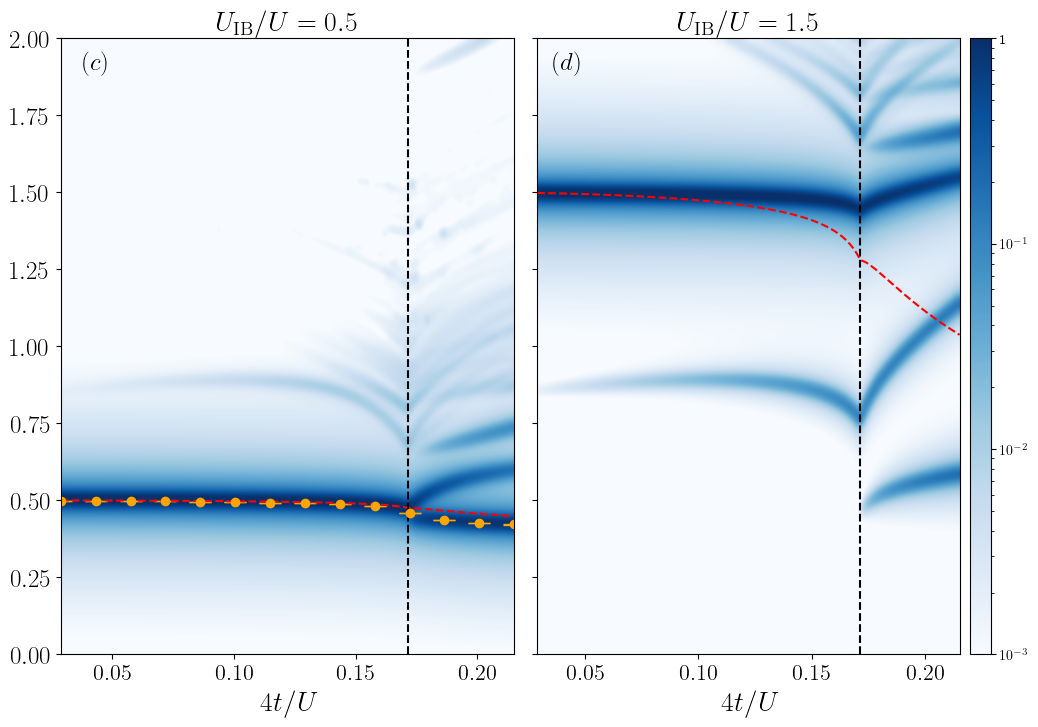

In [83]:
def custom_formatter(x, pos):
    if x == 1:
        return '1'
    else:
        return f'$10^{{{int(np.log10(x))}}}$'



import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['text.usetex'] = True
colorqmc = 'orange'
markerqmc = '.'

# Rotate the image by -90 degrees
# SpectralFuncs_rot05 = np.abs(np.rot90(SpectralFuncs05, 1))
SpectralFuncs_rot10 = np.abs(np.rot90(SpectralFuncs05, 1))
SpectralFuncs_rot15 = np.abs(np.rot90(SpectralFuncs15, 1))


# Apply Gaussian filter to smooth the data
sigma =1  # Adjust sigma to control the amount of smoothing
# SpectralFuncs_rot05 = gaussian_filter(SpectralFuncs_rot05, sigma=sigma)
SpectralFuncs_rot10 = gaussian_filter(SpectralFuncs_rot10, sigma=sigma)
SpectralFuncs_rot15 = gaussian_filter(SpectralFuncs_rot15, sigma=sigma)

fig, (ax2, ax3) = plt.subplots(ncols = 2, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 'auto'
interp = 'bicubic'
color_map = 'Blues'
extent = [min(dJUs), max(dJUs),min(en_vector), max(en_vector) ]

# im1 = ax1.imshow( np.abs(SpectralFuncs_rot05), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())

im2 = ax2.imshow(np.abs(SpectralFuncs_rot10), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())

im3 = ax3.imshow(np.abs(SpectralFuncs_rot15), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())


# ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax2.set_xlabel(r'$4t/U$', fontsize=20)
ax3.set_xlabel(r'$4t/U$', fontsize=20)
# ax1.set_ylabel(r'$\omega/U$', fontsize=14)
# ax1.set_ylim(en_vector[0], en_vector[-1])
# ax1.set_xlabel(r'$4t/U$', fontsize=14)
# ax1.set_ylabel(r'$\omega/U$', fontsize=14)
ax2.set_ylim(en_vector[0], en_vector[-1])
ax2.set_xlabel(r'$4t/U$', fontsize=20)
# ax2.set_ylabel(r'$\omega/U$', fontsize=18)
ax3.set_ylim(en_vector[0], en_vector[-1])
ax3.set_xlabel(r'$4t/U$', fontsize=20)
# ax3.set_ylabel(r'$\omega/U$', fontsize=14)

# ax1.set_title(r'$U_{\mathrm{IB}}/U = 0.5$', fontsize=14)
ax2.set_title(r'$U_{\mathrm{IB}}/U = 0.5$', fontsize=20)
ax3.set_title(r'$U_{\mathrm{IB}}/U = 1.5$', fontsize=20)

# im1.set_clim(1e-3, 1e0)
im2.set_clim(1e-3, 1e0)
im3.set_clim(1e-3, 1e0)

# Create a divider for ax3 to place the colorbar
divider3 = make_axes_locatable(ax3)

# Append an axis for the colorbar to the right of ax3
cax3 = divider3.append_axes("right", size="5%", pad=0.1)

# Create the colorbar
cb3 = plt.colorbar(im3, cax=cax3, orientation="vertical")


# Apply the custom formatter to the colorbar
cb3.ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
# cb3.set_label(label = "-2$\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')


# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_0p5
plot_y_errors = Ep_Error_UIB_0p5
#ax1.scatter(plot_x,plot_y)
# ax1.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert05
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
# ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)

# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_0p5
plot_y_errors = Ep_Error_UIB_0p5
#ax1.scatter(plot_x,plot_y)
ax2.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert10
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax2.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)


# # # plot the extrapolated MC data.
# plot_x = dJUs_Matija_QGW
# plot_y = Ep_Matija_UIB_1p5
# plot_y_errors = Ep_Error_UIB_1p5
# #ax1.scatter(plot_x,plot_y)
# ax3.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert15
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax3.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)
# ax1.legend(loc='upper right')

# Set y-axis limits for all three plots
ylim_lower = 0.25
ylim_upper = 1.7
# ax1.set_ylim(ylim_lower, ylim_upper)
# ax1.tick_params(axis='x', which='major', labelsize=12) 
ax2.tick_params(axis='y', which='major', labelsize=16) 

# ax2.set_ylim(ylim_lower, ylim_upper)
# ax3.set_ylim(ylim_lower, ylim_upper)
# ax2.set_yticklabels([])
ax3.set_yticklabels([])
plt.subplots_adjust(wspace=0.05)

xticks = ax2.get_xticks()
xticklabels = ax2.get_xticklabels()
# increase tick marler size
ax2.tick_params(axis='x', which='major', labelsize=16) 
# ax2.set_xticks(xticks[1:])
# ax2.set_xticklabels(xticklabels[1:])

xticks = ax3.get_xticks()
xticklabels = ax3.get_xticklabels()
ax3.tick_params(axis='x', which='major', labelsize=16) 
# ax3.set_xticks(xticks[1:])
# ax3.set_xticklabels(xticklabels[1:])


ax2.axvline(x=(np.sqrt(2)-1)**2, color='black', linestyle='--')
ax3.axvline(x=(np.sqrt(2)-1)**2, color='black', linestyle='--')
ax2.tick_params(axis='y', which='major', labelsize=18) 
ax3.tick_params(axis='y', which='major', labelsize=18) 

# Add labels (a), (b), and (c) to the panels
# ax1.text(0.13, 0.98, r'$(a)$', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
ax2.text(0.11, 0.98, r'$(c)$', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
ax3.text(0.11, 0.98, r'$(d)$', transform=ax3.transAxes, fontsize=18, fontweight='bold', va='top', ha='right')

plt.show()


In [84]:
filename = f'../figs/self_consistent_t/fig3_pos_UIB_Mu_M_eta_{eta}_cutoff_{cutoff}_full_crossover_fixed_n_neg.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')

In [85]:
# QMC data from Matija
import numpy as np

# conversion between MC and QGW 
# MC data in MI at UIB = 1.5 U
# 0.75 value is interpolate for UIB 1p5
# all values are interpolated for UIB -1p5
MC_to_QGW = 0.1292 / ( 4 * 0.045) # qgw / MC


#hopping
t_Matija_MC= np.array([0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05,0.055,0.06,0.065,0.07,0.075])
#energies

Ep_Matija_UIB_m1p5= np.array([-2.005050723632254, -2.0108809901884954, -2.018810693940047, -2.0293605831181916, -2.0430224590623673, -2.0605610805068117, -2.083479216394353, -2.114512432060115, -2.1612325387061886, -2.2317659578487827, -2.3143705131489356, -2.3632241164105294, -2.376716298494292, -2.3764354596918027])
Ep_Matija_UIB_m1p0 = np.array([-1.0173955050132268, -1.0266931223532272, -1.0362199353983943, -1.0468340235202305, -1.0582427595879502, -1.071882853495497, -1.0895574269571138, -1.1154379306946554, -1.1551084829553062, -1.2157211789833666, -1.2864960288410388, -1.329687074230432, -1.3420089247354257, -1.3452710733877855])
Ep_Matija_UIB_m0p5 = np.array([-0.5005020413820926, -0.5011331466394003, -0.5019494240332274, -0.5029287346363713, -0.5041947930084755, -0.5056389933332792, -0.5071862164659413, -0.508799940903774, -0.5105590478072031, -0.5159499203782498, -0.5312679038700133, -0.5514518336329484, -0.5620778247634112, -0.567813407802312])

#error bars
Ep_Error_UIB_m1p5 = np.array([0.0002107519134027, 0.0002750449921383, 0.0002017096563695, 0.0002228630211733, 7.550187175579104e-05, 0.0002478337910579, 0.0006025158274252, 0.0016625698888594, 0.0033558343901018, 0.0046542553064711, 0.0012476101215255, 0.001542322644204, 0.0035766090629004, 0.0041249878526227])
Ep_Error_UIB_m1p0 = np.array([0.0003822670703627, 0.0007274515072849, 0.0009548699926138, 0.0013080750052027, 0.0013539193449065, 0.0013139528489159, 0.0009810211198714, 0.0002663269305645, 0.0019103850313643, 0.0025786279253415, 0.0003491016427797, 0.0003465767805768, 0.0022127499806375, 0.0022618128224173])
Ep_Error_UIB_m0p5 = np.array([8.006886685879963e-06, 1.150543571563626e-05, 1.6045712226473504e-05, 7.735832504027116e-05, 5.7621164729662104e-05, 0.0001197017765947, 0.0002342575988586, 0.0004024264445344, 0.0004512251574088, 0.0002421209285365, 0.0001347164112716, 0.0001815687987337, 0.0003273543778433, 0.0006233640471457])

#conversion
t_Matija_QGW = MC_to_QGW * t_Matija_MC   
dJUs_Matija_QGW = 4 * t_Matija_QGW

In [86]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

import h5py
import numpy as np
eta = 0.01
desired_n0 = 1.01 # desired density line
M = 100
cutoff = 3

UIB = -0.5
filename05 = f'../data/UIB_{UIB}_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5'
# UIB_0.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5
# UIB_0.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5
print(filename05)
data05 = read_hdf5_file(filename05)
omega0s = data05['omega0s']
omega1s = data05['omega1s']
omega2s = data05['omega2s']
SpectralFuncs05 = data05['SpectralFuncs']
pert05 = omega0s + omega1s + omega2s
pert10 = pert05

UIB = -1.5
filename15 = f'../data/UIB_{UIB}_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5'
print(filename15)
data15 = read_hdf5_file(filename15)
omega0s = data15['omega0s']
omega1s = data15['omega1s']
omega2s = data15['omega2s']
SpectralFuncs15 = data15['SpectralFuncs']
pert15 = omega0s + omega1s + omega2s


dJUs = np.linspace(0.02871,0.2154,200)
en_vector = data15['en_vector']

# First row of SpectralFuncs05 should be equal to second

# SpectralFuncs05[0, :] = SpectralFuncs05[1, :]

../data/UIB_-0.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5
../data/UIB_-1.5_M_100_N_7_num_en_200_num_dJU_200_dJU_max_0.2154_eta_0.01_cutoff_3_full_crossover.hdf5


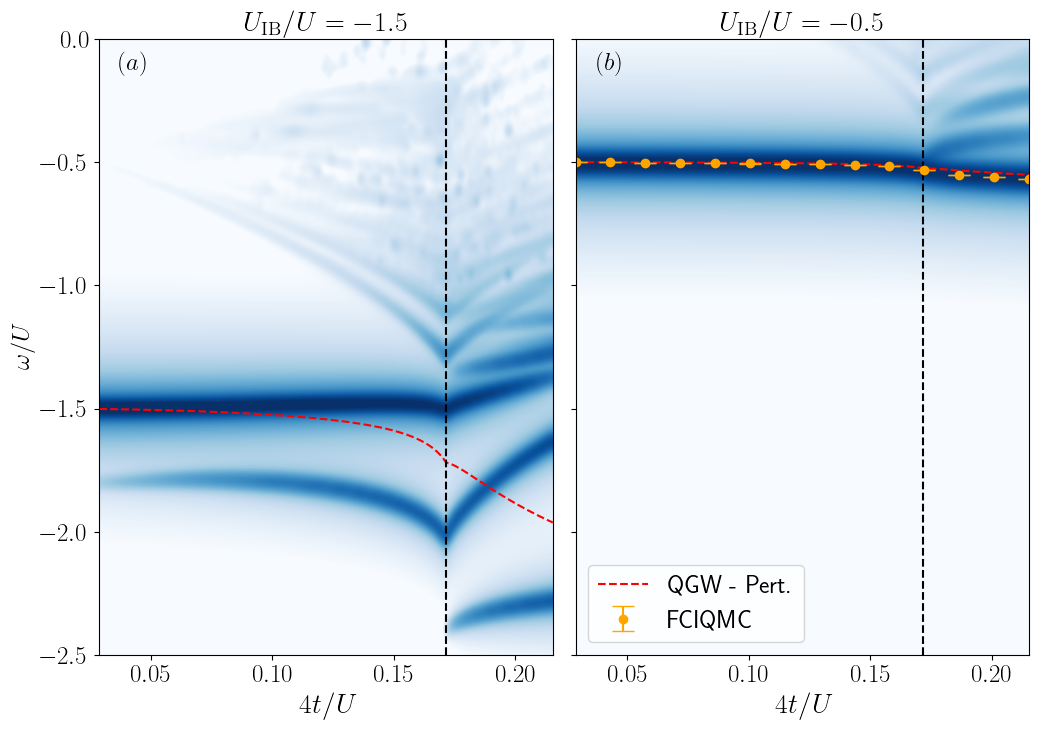

In [87]:
def custom_formatter(x, pos):
    if x == 1:
        return '1'
    else:
        return f'$10^{{{int(np.log10(x))}}}$'


colorqmc = 'orange'
markerqmc = '.'
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['text.usetex'] = True


# Rotate the image by -90 degrees
SpectralFuncs_rot05 = np.abs(np.rot90(SpectralFuncs05, 1))
SpectralFuncs_rot10 = np.abs(np.rot90(SpectralFuncs05, 1))
SpectralFuncs_rot15 = np.abs(np.rot90(SpectralFuncs15, 1))


# Apply Gaussian filter to smooth the data
sigma =1  # Adjust sigma to control the amount of smoothing
SpectralFuncs_rot05 = gaussian_filter(SpectralFuncs_rot05, sigma=sigma)
SpectralFuncs_rot10 = gaussian_filter(SpectralFuncs_rot05, sigma=sigma)
SpectralFuncs_rot15 = gaussian_filter(SpectralFuncs_rot15, sigma=sigma)

fig, (ax3, ax2) = plt.subplots(ncols = 2, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 'auto'
interp = 'Bicubic'
color_map = 'Blues'
extent = [min(dJUs), max(dJUs),min(en_vector), max(en_vector) ]

# im1 = ax1.imshow( np.abs(SpectralFuncs_rot05), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())

im2 = ax2.imshow(np.abs(SpectralFuncs_rot10), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())

im3 = ax3.imshow(np.abs(SpectralFuncs_rot15), interpolation = interp, cmap=color_map, aspect = aspect_ratio, extent = extent, norm=colors.LogNorm())


# ax1.set_xlabel(r'$4t/U$', fontsize=14)
ax2.set_xlabel(r'$4t/U$', fontsize=20)
ax3.set_xlabel(r'$4t/U$', fontsize=20)
# ax1.set_ylabel(r'$\omega/U$', fontsize=14)
# ax1.set_ylim(en_vector[0], en_vector[-1])
# ax1.set_xlabel(r'$4t/U$', fontsize=14)
# ax1.set_ylabel(r'$\omega/U$', fontsize=14)
ax2.set_ylim(en_vector[0], en_vector[-1])
ax2.set_xlabel(r'$4t/U$', fontsize=20)
# ax2.set_ylabel(r'$\omega/U$', fontsize=18)
ax3.set_ylim(en_vector[0], en_vector[-1])
ax3.set_xlabel(r'$4t/U$', fontsize=20)
ax3.set_ylabel(r'$\omega/U$', fontsize=18)

# ax1.set_title(r'$U_{\mathrm{IB}}/U = -0.5$', fontsize=14)
ax2.set_title(r'$U_{\mathrm{IB}}/U = -0.5$', fontsize=20)
ax3.set_title(r'$U_{\mathrm{IB}}/U = -1.5$', fontsize=20)

# im1.set_clim(1e-3, 1e0)
im2.set_clim(1e-3, 1e0)
im3.set_clim(1e-3, 1e0)

# # Create a divider for ax3 to place the colorbar
# divider3 = make_axes_locatable(ax3)

# # Append an axis for the colorbar to the right of ax3
# cax3 = divider3.append_axes("right", size="5%", pad=0.1)

# # Create the colorbar
# cb3 = plt.colorbar(im3, cax=cax3, orientation="vertical")


# # Apply the custom formatter to the colorbar
# cb3.ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
# # cb3.set_label(label = "-2$\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')


# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_m0p5
plot_y_errors = Ep_Error_UIB_m0p5
#ax1.scatter(plot_x,plot_y)
# ax1.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 4,linestyle = 'none',capsize = 3, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert05
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
# ax1.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)

# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_m1p0
plot_y_errors = Ep_Error_UIB_m1p0
#ax1.scatter(plot_x,plot_y)
# ax2.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)

#plot perturbative result
plot_x = dJUs
plot_y = pert10
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax2.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)

# # # plot the extrapolated MC data.
plot_x = dJUs_Matija_QGW
plot_y = Ep_Matija_UIB_m0p5
plot_y_errors = Ep_Error_UIB_m0p5
#ax1.scatter(plot_x,plot_y)
ax2.errorbar(plot_x, plot_y, yerr = plot_y_errors  , marker = markerqmc,markersize = 12,linestyle = 'none',capsize = 8, label='FCIQMC', color=colorqmc)
ax3.tick_params(axis='y', which='major', labelsize=14) 

#plot perturbative result
plot_x = dJUs
plot_y = pert15
# fig.suptitle(f"Results UIB/U = {UIB:0.2f}, Total Sites = {M}", fontsize = 20)
ax3.plot(plot_x, plot_y, linestyle = '--', label='QGW - Pert.', color='red', linewidth=1.5)

# set legend location
# ax1.legend(loc='upper right')

# Add labels (a), (b), and (c) to the panels
# ax1.text(0.13, 0.98, r'$(a)$', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
# ax2.text(0.13, 0.98, r'$(b)$', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
# ax3.text(0.13, 0.98, r'$(c)$', transform=ax3.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
ax2.set_yticklabels([])
# ax3.set_yticklabels([])
plt.subplots_adjust(wspace=0.05)

xticks = ax2.get_xticks()
xticklabels = ax2.get_xticklabels()
# ax2.set_xticks(xticks[1:])
# ax2.set_xticklabels(xticklabels[1:])

xticks = ax3.get_xticks()
xticklabels = ax3.get_xticklabels()
# ax3.set_xticks(xticks[1:])
# ax3.set_xticklabels(xticklabels[1:])

# Set y-axis limits for all three plots
ylim_lower = -2.5
ylim_upper = 0
# ax1.set_ylim(ylim_lower, ylim_upper)
ax2.set_ylim(ylim_lower, ylim_upper)
ax3.set_ylim(ylim_lower, ylim_upper)

# ax1.tick_params(axis='x', which='major', labelsize=12) 
# ax1.tick_params(axis='y', which='major', labelsize=12) 
# increase tick marler size
ax2.tick_params(axis='x', which='major', labelsize=18) 

ax3.tick_params(axis='x', which='major', labelsize=18) 

ax2.tick_params(axis='y', which='major', labelsize=18) 
ax3.tick_params(axis='y', which='major', labelsize=18) 
ax2.axvline(x=(np.sqrt(2)-1)**2, color='black', linestyle='--')
ax3.axvline(x=(np.sqrt(2)-1)**2, color='black', linestyle='--')

# Add labels (a), (b), and (c) to the panels
# ax1.text(0.13, 0.98, r'$(a)$', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
ax2.text(0.11, 0.98, r'$(b)$', transform=ax2.transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
ax3.text(0.11, 0.98, r'$(a)$', transform=ax3.transAxes, fontsize=18, fontweight='bold', va='top', ha='right')
ax2.legend(loc='lower left', fontsize=18)
plt.show()


In [88]:
filename = f'../figs/self_consistent_t/fig3_neg_UIB_Mu_M_eta_{eta}_cutoff_{cutoff}_full_crossover_fixed_n_neg.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')